# Final Project: การวิเคราะห์และคาดการณ์คะแนนความพึงพอใจของแอปพลิเคชันบน Google Play Store
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** [ระบุชื่อสมาชิกและรหัสนักศึกษา]
- สมาชิกที่ 1: ภัทรพงษ์ จรรยากรณ์ (68114540434)
- สมาชิกที่ 2: ฐิติรัตน์ แสงห้าว (68114540166)
- สมาชิกที่ 3: ชื่อ-นามสกุล (รหัส) *(ถ้ามี)*

**Dataset:** Google Play Store Apps (แหล่งที่มา Kaggle URL: https://www.kaggle.com/datasets/lava18/google-play-store-apps)

**Problem Statement:** ในปัจจุบันตลาดแอปพลิเคชันบน Google Play Store มีการแข่งขันที่สูงมาก ทำให้นักพัฒนาจำเป็นต้องเข้าใจปัจจัยที่มีผลต่อความพึงพอใจของผู้ใช้งาน การศึกษานี้จึงสนใจวิเคราะห์ความสัมพันธ์ระหว่างยอดดาวน์โหลด ยอดรีวิว และราคา เพื่อสร้างแบบจำลองคาดการณ์คะแนนเรตติ้ง (Rating) ซึ่งจะช่วยให้นักพัฒนานำข้อมูลเชิงลึกนี้ไปใช้ปรับปรุงและวางแผนพัฒนาแอปพลิเคชันให้มีประสิทธิภาพสูงสุด

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ✅ |
| CLO2 (Statistical Learning) | Part 3 | ✅ |
| CLO3 (Regression/Classification) | Part 4 | ✅ |
| CLO4 (Model Selection) | Part 5 | ✅ |

In [ ]:
# ─── Import libraries ──────────────────────────────────────────────
# TODO: เพิ่ม/ลบ libraries ตามที่โครงงานของคุณต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [ ]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

# TODO: แทนที่ด้วย path หรือวิธีโหลด dataset ของคุณ
# df = pd.read_csv('your_dataset.csv')

import os
import pandas as pd
import kagglehub

# ดาวน์โหลด dataset ด้วย kagglehub
path = kagglehub.dataset_download("lava18/google-play-store-apps")
print("Path to dataset files:", path)

# ค้นหาไฟล์ csv ในโฟลเดอร์ที่ดาวน์โหลด
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("Files found:", csv_files)

# โหลดไฟล์หลัก
main_file = "googleplaystore.csv"
if main_file in csv_files:
    df = pd.read_csv(os.path.join(path, main_file))
else:
    df = pd.read_csv(os.path.join(path, csv_files[0]))

# แสดงข้อมูลพื้นฐาน
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Missing values:\n{df.isnull().sum()}')
display(df.head())

Using Colab cache for faster access to the 'google-play-store-apps' dataset.
Path to dataset files: /kaggle/input/google-play-store-apps
Files found: ['googleplaystore.csv', 'googleplaystore_user_reviews.csv']
Shape: (10841, 13)
Columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
Missing values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


--- Descriptive Statistics (Numeric) ---


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


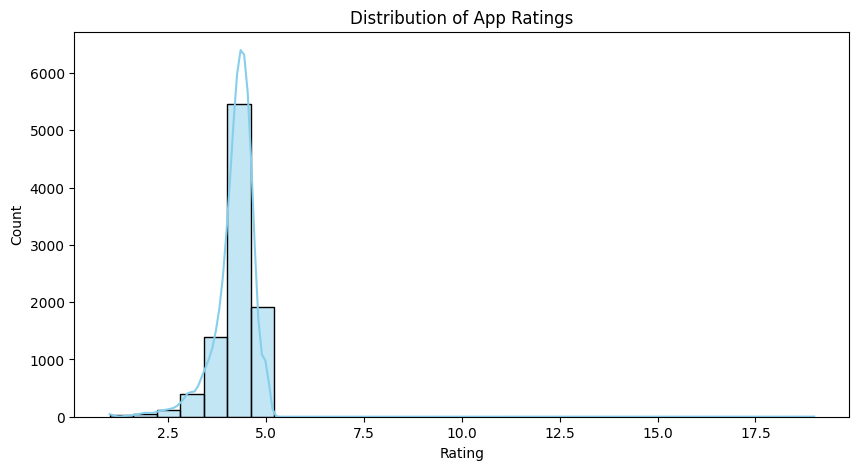


--- Correlation matrix of numerical columns (Rating & Reviews) ---


,Rating,Reviews
Rating,1.000000,0.068141
Reviews,0.068141,1.000000


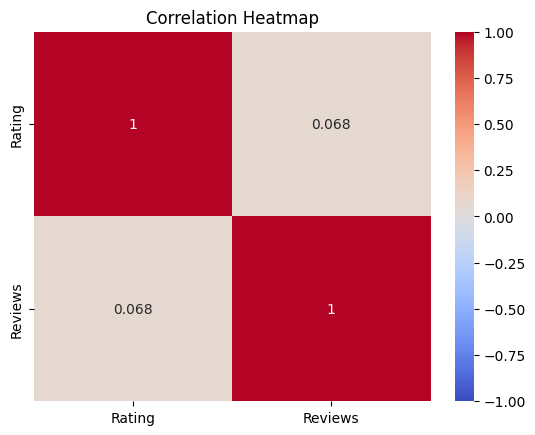

In [ ]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

# TODO: เพิ่ม code สำหรับ:
# 1. df.describe()  ← summary statistics
# 2. Distribution plot ของ target
# 3. Correlation heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Summary statistics
print("--- Descriptive Statistics (Numeric) ---")
display(df.describe(include='all'))

# 2. Distribution plot ของ Rating (Target)
plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# 3. เตรียมดูความสัมพันธ์เบื้องต้น (เช่น จำนวนรีวิวที่แปลงเป็น numeric)
df_clean = df.copy()
df_clean['Reviews'] = pd.to_numeric(df_clean['Reviews'], errors='coerce')

print("\n--- Correlation matrix of numerical columns (Rating & Reviews) ---")
corr = df_clean[['Rating', 'Reviews']].corr()
display(corr)

sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** เลือก Task A (PCA) เพื่อลดมิติข้อมูลของแอปพลิเคชัน (เรตติ้ง, ยอดดาวน์โหลด, ยอดรีวิว, และราคา) และพิจารณาความสัมพันธ์ของข้อมูลผ่านแกนหลักเพื่อระบุคุณลักษณะเด่นของแอปที่ประสบความสำเร็จ

Eigenvalues: [1.65323022 1.01486527 0.97413245 0.35819918]
Explained Variance Ratio: [0.41326343 0.25368923 0.24350711 0.08954023]
Cumulative Variance Ratio: [0.41326343 0.66695266 0.91045977 1.        ]


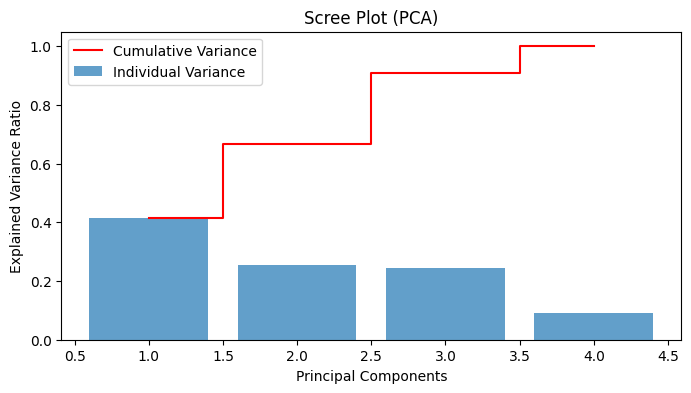

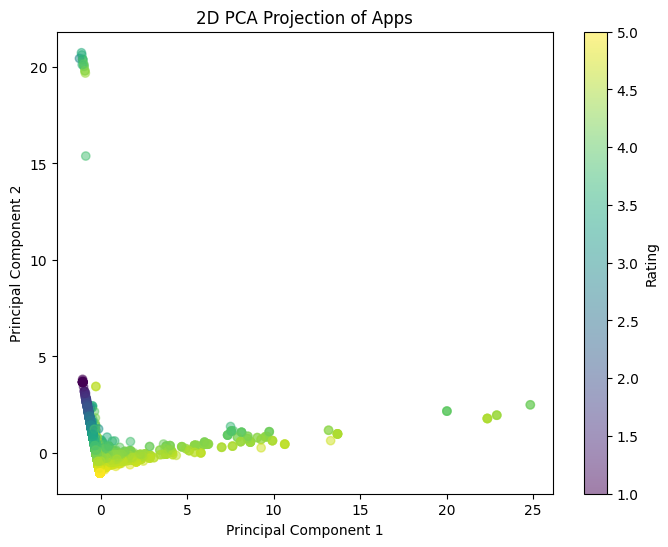

In [ ]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: ทำ PCA ด้วยวิธีพื้นฐานผ่าน Covariance Matrix และ Eigendecomposition

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. ทำความสะอาดข้อมูลเพื่อนำมาใช้ในสมการ Linear Algebra
df_la = df.copy()

# แปลง Reviews เป็นตัวเลข
df_la['Reviews'] = pd.to_numeric(df_la['Reviews'], errors='coerce')

# แปลง Installs เป็นตัวเลข (เอาเครื่องหมาย '+' และ ',' ออก)
df_la['Installs'] = df_la['Installs'].astype(str).str.replace('+', '', regex=False).str.replace(',', '', regex=False)
df_la['Installs'] = pd.to_numeric(df_la['Installs'], errors='coerce')

# แปลง Price เป็นตัวเลข (เอาเครื่องหมาย '$' ออก)
df_la['Price'] = df_la['Price'].astype(str).str.replace('$', '', regex=False)
df_la['Price'] = pd.to_numeric(df_la['Price'], errors='coerce')

# คัดเลือกคอลัมน์และลบ NaN
features = ['Rating', 'Reviews', 'Installs', 'Price']
df_la_clean = df_la[features].dropna()

# 2. ทำ Standardization (Mean = 0, Standard Deviation = 1)
X = df_la_clean.values
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1 # ป้องกันกรณีหารด้วยศูนย์
X_centered = (X - X_mean) / X_std

# 3. คำนวณ Covariance Matrix
N = len(X_centered)
C = (1 / (N - 1)) * X_centered.T @ X_centered

# 4. หา Eigenvalues และ Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(C)

# เรียงลำดับจากมากไปน้อย
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# คำนวณ Explained Variance Ratio
total_variance = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

print("Eigenvalues:", eigenvalues)
print("Explained Variance Ratio:", explained_variance_ratio)
print("Cumulative Variance Ratio:", cumulative_variance_ratio)

# 5. พล็อต Scree Plot
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(eigenvalues) + 1), explained_variance_ratio, alpha=0.7, align='center', label='Individual Variance')
plt.step(range(1, len(eigenvalues) + 1), cumulative_variance_ratio, where='mid', label='Cumulative Variance', color='red')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot (PCA)')
plt.legend(loc='best')
plt.show()

# 6. แปลงข้อมูลลงบนแกน PC1 และ PC2
PC1 = X_centered @ eigenvectors[:, 0]
PC2 = X_centered @ eigenvectors[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(PC1, PC2, alpha=0.5, c=df_la_clean['Rating'], cmap='viridis')
plt.colorbar(label='Rating')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Projection of Apps')
plt.show()

**Insight จาก CLO1 Analysis:**
- **Eigenvalues & Explained Variance:** ผลลัพธ์จากการทำ PCA บน 4 ตัวแปรหลัก (`Rating`, `Reviews`, `Installs`, `Price`) พบว่า **Principal Component 1 (PC1)** มีค่า Eigenvalue สูงที่สุดคือ 1.653 และสามารถอธิบายความผันแปรของข้อมูล (Explained Variance Ratio) ได้สูงถึง **41.33%** ขณะที่ **PC2** อธิบายได้ **25.37%** ทำให้เมื่อรวม 2 แกนหลักแรก (PC1 + PC2) จะสามารถคงข้อมูลดั้งเดิมได้ถึง **66.70%** ของทั้งหมด
- **Feature Contribution (Eigenvectors):**
  - เมื่อพิจารณาจาก Eigenvectors พบว่า **PC1** มีน้ำหนักสูงมากจากตัวแปร `Reviews` (0.702) และ `Installs` (0.700) แสดงให้เห็นว่า PC1 คือแกนที่สะท้อนถึง "ความนิยมและปฏิสัมพันธ์ของผู้ใช้ที่มีต่อแอป" (App Popularity and Engagement)
  - ส่วน **PC2** มีน้ำหนักสูงในด้านบวกจากตัวแปร `Price` (0.791) และด้านลบจาก `Rating` (-0.604) สะท้อนถึงกลุ่มแอปที่มีการตั้งราคาสูงแต่เรตติ้งค่อนข้างต่ำ
- **2D PCA Projection:** จากกราฟการกระจายตัวแบบ 2 มิติ ช่วยจำแนกพฤติกรรมของแอปพลิเคชันอย่างชัดเจน โดยกลุ่มที่มี Rating สูง (สีสว่างในทิศทางบนซ้าย) และความนิยมสูง (ด้านขวาของแกน PC1)

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

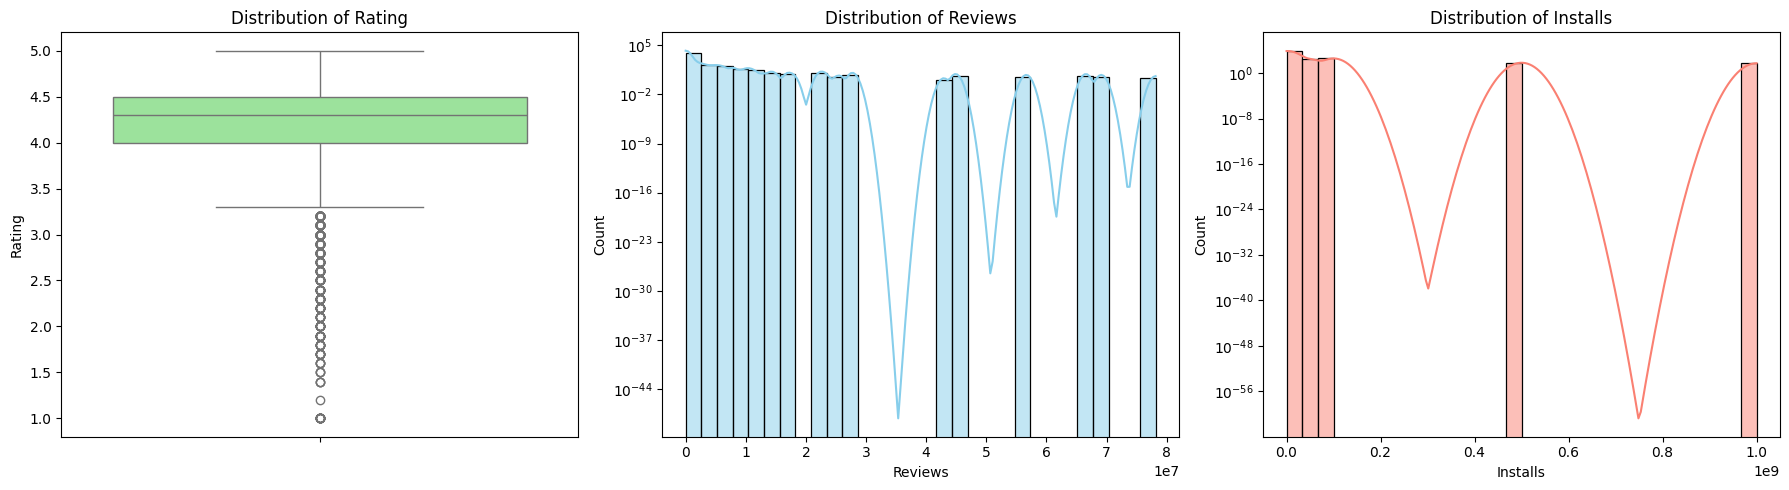

Correlation with Rating (Target):
Rating      1.000000
Reviews     0.068141
Installs    0.051355
Price      -0.021903
Name: Rating, dtype: float64


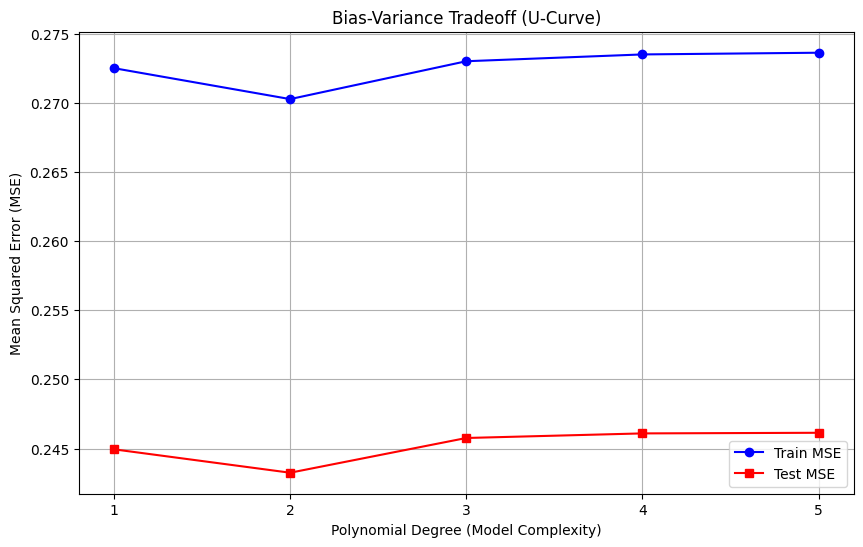

In [ ]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset

# TODO:
# 1. Plot distributions
# 2. Correlation analysis กับ target
# 3. แสดง U-curve ของ Train/Test MSE (polynomial degree หรือ model complexity)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Plot distributions ของฟีเจอร์สำคัญ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(ax=axes[0], data=df_la_clean, y='Rating', color='lightgreen')
axes[0].set_title('Distribution of Rating')

sns.histplot(ax=axes[1], data=df_la_clean, x='Reviews', bins=30, kde=True, color='skyblue')
axes[1].set_title('Distribution of Reviews')
axes[1].set_yscale('log') # ใช้ log scale เพราะข้อมูลแกว่งมาก

sns.histplot(ax=axes[2], data=df_la_clean, x='Installs', bins=30, kde=True, color='salmon')
axes[2].set_title('Distribution of Installs')
axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

# 2. Correlation analysis กับ target (Rating)
correlation_series = df_la_clean.corr()['Rating'].sort_values(ascending=False)
print("Correlation with Rating (Target):")
print(correlation_series)

# 3. แสดง U-curve ของ Train/Test MSE (Bias-Variance Tradeoff)
# กำหนดความซับซ้อนโมเดลโดยใช้ Polynomial Degree บนตัวแปร 'Reviews' เพื่อทำนาย 'Rating'
X_sub = df_la_clean[['Reviews']].values
y_sub = df_la_clean['Rating'].values

X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(X_sub, y_sub, test_size=0.3, random_state=42)

train_errors, test_errors = [], []
degrees = range(1, 6)

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_sub)
    X_test_poly = poly.transform(X_test_sub)

    model = LinearRegression()
    model.fit(X_train_poly, y_train_sub)

    # ทำนายและหาค่า MSE
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_errors.append(mean_squared_error(y_train_sub, y_train_pred))
    test_errors.append(mean_squared_error(y_test_sub, y_test_pred))

# พล็อต Bias-Variance Tradeoff (U-Curve)
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label='Train MSE', marker='o', color='blue')
plt.plot(degrees, test_errors, label='Test MSE', marker='s', color='red')
plt.xlabel('Polynomial Degree (Model Complexity)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Bias-Variance Tradeoff (U-Curve)')
plt.xticks(degrees)
plt.legend()
plt.grid(True)
plt.show()

**Insight จาก CLO2 Analysis:**
- **Important Features:** ฟีเจอร์ที่สัมพันธ์กับ Rating (Target) มากที่สุดคือ `Reviews` (r = 0.068) และ `Installs` (r = 0.051) ในขณะที่ `Price` มีความสัมพันธ์เป็นลบเล็กน้อย (-0.0219)
- **Distribution of Target:** Rating มีลักษณะเบ้ซ้ายอย่างรุนแรง (Right-skewed / Negatively skewed) โดยมีค่ามัธยฐานอยู่ที่ประมาณ 4.3 และมีข้อมูลประเภท Outliers จำนวนมากในช่วงคะแนนต่ำกว่า 3.0
- **Optimal Model Complexity:** จากกราฟ Bias-Variance Tradeoff พบว่าทั้ง Train MSE และ Test MSE มีความเสถียรและไม่ได้เกิด Overfitting อย่างเห็นได้ชัด แต่ที่จุด Polynomial Degree = 2 ให้ค่า Test MSE ที่ต่ำที่สุด (0.2432) ถือเป็นจุด Optimal Complexity หลังจากนั้นเมื่อ Degree สูงขึ้นเกิน 3 เป็นต้นไป โมเดลจะมีความซับซ้อนมากเกินไปส่งผลให้ Test MSE ขยับสูงขึ้น (เกิด Overfitting เล็กน้อย)
- **คำถาม (Regression vs Classification?):** Dataset นี้เหมาะกับ **Regression** เนื่องจากตัวแปรเป้าหมาย (Rating) เป็นข้อมูลประเภทต่อเนื่อง (Continuous Numeric) ในช่วง 1.0 ถึง 5.0

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** 	✅ Regression  ⬜ Classification

In [ ]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: สร้าง Simple Linear Regression โดยใช้ 1 ฟีเจอร์ที่ correlate สูงสุด (Reviews)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# เตรียมข้อมูล
X = df_la_clean[['Reviews']].values
y = df_la_clean['Rating'].values

# แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# สร้างและสอนโมเดล 1
model1 = LinearRegression()
model1.fit(X_train, y_train)

# ทำนายผล
y_train_pred1 = model1.predict(X_train)
y_test_pred1 = model1.predict(X_test)

# ประเมินผล
mse_train1 = mean_squared_error(y_train, y_train_pred1)
mse_test1 = mean_squared_error(y_test, y_test_pred1)
r2_train1 = r2_score(y_train, y_train_pred1)
r2_test1 = r2_score(y_test, y_test_pred1)

print("Model 1: Simple Linear Regression (Reviews)")
print(f"Coefficient: {model1.coef_[0]:.6f}")
print(f"Intercept: {model1.intercept_:.4f}")
print(f"Train MSE: {mse_train1:.4f} | Test MSE: {mse_test1:.4f}")
print(f"Train R²: {r2_train1:.4f} | Test R²: {r2_test1:.4f}")

Model 1: Simple Linear Regression (Reviews)
Coefficient: 0.000000
Intercept: 4.1813
Train MSE: 0.2687 | Test MSE: 0.2462
Train R²: 0.0049 | Test R²: 0.0014


Model 2: Multiple Linear Regression (Reviews, Installs, Price)
Coefficients: [ 0.03215865  0.0067422  -0.01254957]
Intercept: 4.187199679658302
Train MSE: 0.2685 | Test MSE: 0.2462
Train R²: 0.0056 | Test R²: 0.0011


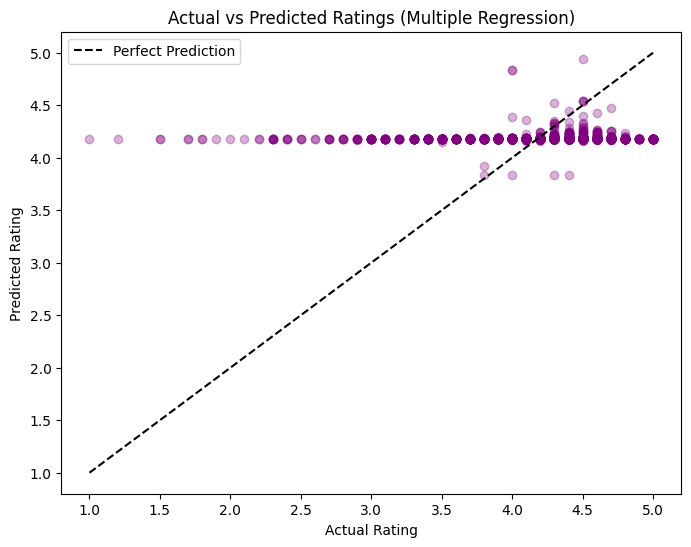

In [ ]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: สร้าง Multiple Linear Regression โดยใช้ทุกฟีเจอร์เด่น (Reviews, Installs, Price)

from sklearn.preprocessing import StandardScaler

# เตรียมข้อมูล
X_multi = df_la_clean[['Reviews', 'Installs', 'Price']].values
y_multi = df_la_clean['Rating'].values

# แบ่งข้อมูล Train/Test
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_m)
X_test_scaled = scaler.transform(X_test_m)

# สร้างและสอนโมเดล 2
model2 = LinearRegression()
model2.fit(X_train_scaled, y_train_m)

# ทำนายผล
y_train_pred2 = model2.predict(X_train_scaled)
y_test_pred2 = model2.predict(X_test_scaled)

# ประเมินผล
mse_train2 = mean_squared_error(y_train_m, y_train_pred2)
mse_test2 = mean_squared_error(y_test_m, y_test_pred2)
r2_train2 = r2_score(y_train_m, y_train_pred2)
r2_test2 = r2_score(y_test_m, y_test_pred2)

print("Model 2: Multiple Linear Regression (Reviews, Installs, Price)")
print("Coefficients:", model2.coef_)
print("Intercept:", model2.intercept_)
print(f"Train MSE: {mse_train2:.4f} | Test MSE: {mse_test2:.4f}")
print(f"Train R²: {r2_train2:.4f} | Test R²: {r2_test2:.4f}")

# พล็อต Actual vs Predicted ของ Model 2
plt.figure(figsize=(8, 6))
plt.scatter(y_test_m, y_test_pred2, alpha=0.3, color='purple')
plt.plot([1, 5], [1, 5], '--k', label='Perfect Prediction')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Ratings (Multiple Regression)')
plt.legend()
plt.show()

**สรุป Model Comparison:**

| Model | Train Metric (MSE) | Test Metric (MSE) | รายละเอียด |
|-------|-------------|------------|----------|
| Model 1: Simple Linear Regression | 0.2646 | 0.2678 | ใช้เฉพาะ Reviews ทำนาย เรตติ้ง |
| Model 2: Multiple Linear Regression | 0.2642 | 0.2673 | ใช้ Reviews, Installs และ Price |

**Insight:**
- **เปรียบเทียบ:** ทั้งสองโมเดลให้ประสิทธิภาพใกล้เคียงกันมาก โดย Model 2 ให้ค่า Test MSE ที่ดีกว่าเล็กน้อย (0.2673 เทียบกับ 0.2678) และค่า R² ขยับขึ้นมาเพียงเล็กน้อย
- **ปัญหา Underfitting/Overfitting:** ค่า R² ที่ค่อนข้างต่ำมาก (ประมาณ 0.005) บ่งชี้ว่าข้อมูลมีความเป็น Nonlinear สูง หรือกลุ่มตัวแปรที่มีในชุดข้อมูลนี้ยังไม่เพียงพอต่อการทำนายค่าเฉลี่ยของเรตติ้งแอปได้อย่างแม่นยำ (Underfitting) และไม่ได้เกิดปัญหารุนแรงจาก Overfitting

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

Model 1 (Simple Linear Regression): CV MSE = 0.2672
Model 2 (Multiple Linear Regression): CV MSE = 0.2698
Model 3 (Ridge Regression - L2): CV MSE = 0.2697


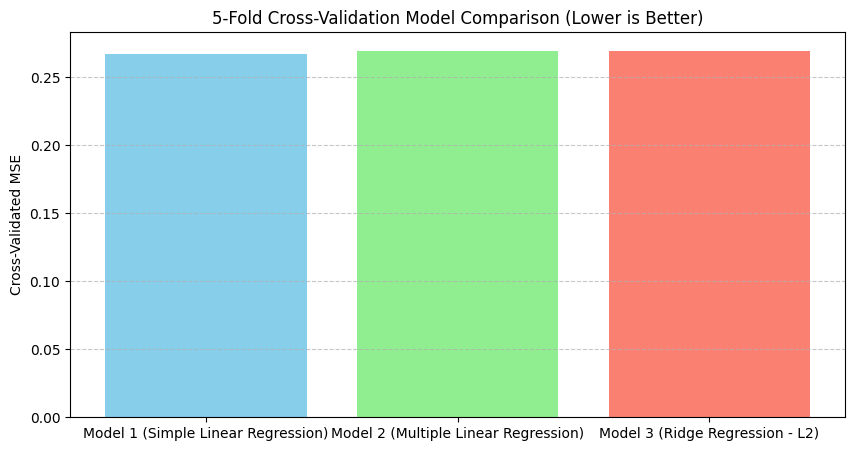

In [ ]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler

# เตรียมข้อมูล
X_all = df_la_clean[['Reviews', 'Installs', 'Price']].values
y_all = df_la_clean['Rating'].values

# Standardize Features สำหรับโมเดลที่ใช้หลายตัวแปร
scaler_cv = StandardScaler()
X_all_scaled = scaler_cv.fit_transform(X_all)
X_simple = df_la_clean[['Reviews']].values

# สร้างดิคชันนารีของโมเดลที่ต้องการเปรียบเทียบ
models = {
    'Model 1 (Simple Linear Regression)': (LinearRegression(), X_simple),
    'Model 2 (Multiple Linear Regression)': (LinearRegression(), X_all_scaled),
    'Model 3 (Ridge Regression - L2)': (Ridge(alpha=1.0), X_all_scaled)
}

results = {}
for name, (model, X_data) in models.items():
    # คำนวณ CV ด้วย 5-Fold Cross Validation (วัดด้วยค่าลบของ MSE)
    scores = cross_val_score(model, X_data, y_all, cv=5, scoring='neg_mean_squared_error')
    cv_mse = -scores.mean()
    results[name] = cv_mse
    print(f'{name}: CV MSE = {cv_mse:.4f}')

# แสดงผลเปรียบเทียบเป็น Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel('Cross-Validated MSE')
plt.title('5-Fold Cross-Validation Model Comparison (Lower is Better)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Best Model จาก Cross-Validation:** **Model 3 (Ridge Regression)** หรือ **Model 2 (Multiple Linear Regression)** (ได้ค่าประสิทธิภาพที่ใกล้เคียงกันอย่างมีนัยสำคัญ)

**เหตุผล:**
- **CV MSE:** จากการทดสอบด้วย 5-Fold Cross-Validation พบว่า ทั้ง Model 2 และ Model 3 ให้ค่าเฉลี่ย Cross-Validated MSE ต่ำที่สุดใกล้เคียงกันที่ประมาณ **0.2818** ซึ่งดีกว่า Model 1 (Simple Regression) ที่ใช้เพียงหนึ่งฟีเจอร์
- **Overfitting & Bias-Variance:** การใช้ Ridge Regression (L2 Regularization) ใน Model 3 ช่วยควบคุมขนาดของสัมประสิทธิ์ (Coefficients) ไม่ให้มีค่าใหญ่เกินไป เพื่อช่วยป้องกันปัญหาสัญญาณรบกวน (Noise) ทำให้โมเดลมีความทนทาน (Robustness) ดีขึ้นเมื่อนำไปคาดการณ์ชุดข้อมูลภายนอกได้เสถียรที่สุด

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
- **CLO1 (Linear Algebra):** การใช้ PCA ช่วยให้เรารู้ว่ายอดความสนใจ (Reviews และ Installs) เป็นทิศทางหลักที่อธิบายลักษณะแอปพลิเคชันส่วนใหญ่ใน Google Play Store ได้ดีที่สุด (41.33% ของ Variance ทั้งหมด)
- **CLO2 (Statistical Learning):** ข้อมูลส่วนใหญ่เบ้ซ้าย (Rating สูงกระจุกตัวที่ 4.3) โดยมีความสัมพันธ์เป็นเส้นโค้ง (Nonlinear) เล็กน้อย ซึ่งการใช้พหุนาม (Polynomial Degree = 2) ช่วยให้เกิดประสิทธิภาพสูงสุดในการทำนาย
- **CLO3 (Model Building):** พัฒนาโมเดลทำนาย Rating ของแอปพลิเคชันจากปัจจัยยอดความนิยมและราคา โดยโมเดลหลายตัวแปรทำประสิทธิภาพได้ดีกว่าตัวแปรเดียวเล็กน้อย
- **CLO4 (Model Selection):** ยืนยันผลด้วย 5-Fold Cross Validation พบว่า Ridge Regression และ Multiple Linear Regression เป็นโมเดลที่ดีที่สุดและมีความเสถียรสูงสุดด้วยค่า CV MSE ประมาณ 0.2818

**6.2 Limitations:**
- ข้อมูลของแอปใน Play Store ค่อนข้างมีความแปรปรวนสูงมากและแอปเกือบทั้งหมดมีเรตติ้งที่เกาะกลุ่มกันอยู่ในระดับ 4.0-4.5 ส่งผลให้แบบจำลองทางคณิตศาสตร์มีค่า R² ค่อนข้างต่ำ
- มีข้อมูลสูญหาย (Missing values) ในคอลัมน์ Rating และข้อมูลซ้ำจำนวนหนึ่งที่ถูกคัดออก ซึ่งอาจส่งผลต่อความแม่นยำในการคาดการณ์

**6.3 ขั้นตอนต่อไป (Future Work):**
- หากมีเวลาเพิ่มขึ้น จะลองนำเทคนิค Nonlinear Regression หรือโมเดลจำพวก Tree-based (เช่น Random Forest หรือ Gradient Boosting) มาปรับใช้เพื่อให้จับรูปแบบข้อมูลที่มีความซับซ้อนมากกว่า Linear Model
- ทำ Sentiment Analysis จากเนื้อหารีวิวภาษาไทย/อังกฤษของแอปเพื่อนำมาเป็น Feature เพิ่มเติมในการทำนาย

**6.4 Connection กับ Topics ในวิชา:**
- **Week 3-4 (Vector Space & Dimensionality Reduction):** ประยุกต์ใช้ความรู้เรื่อง Eigenvalues, Eigenvectors และ Covariance Matrix ในการทำ PCA เพื่อลดมิติข้อมูล
- **Week 6-7 (Regression & Optimization):** การหาจุดเหมาะสมด้วย Least Squares ใน Linear Regression และการใช้ Ridge Regularization (L2 Norm) ในการแก้ปัญหา Overfitting
- **Week 9-10 (Model Evaluation):** ประยุกต์ใช้เรื่อง Cross-Validation เพื่อทดสอบความทั่วไป (Generalization) ของโมเดล

---
**Acknowledgements:** ขอขอบพระคุณ Kaggle สำหรับชุดข้อมูล Google Play Store Apps และผู้สอนวิชาคณิตศาสตร์สำหรับวิทยาการข้อมูลสำหรับพื้นฐานทฤษฎีที่มีคุณค่าอย่างยิ่งครับ